In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
%config InlineBackend.figure_format = "retina"

In [2]:
def admm_state_estimation(
    A, b, x_initial, lambda_reg, rho=1.0, tol=1e-4, max_iters=1000
):
    """
    Maybe (?) solve the state estimation problem via ADMM.

    Hessian calculation is a mess/sketchy?

    Not sure how to generalize to coupling.

    Parameters:
      A         : (obs_dim x state_dim) linear operator.
      b         : (T x obs_dim) observed data.
      x_initial : (state_dim,) user-specified initial condition for time t=0.
      lambda_reg : (state_dim,) vector of smoothing weights.
      rho       : ADMM penalty parameter (default: 1.0).
      tol       : Tolerance for convergence (default: 1e-4).
      max_iters : Maximum number of ADMM iterations (default: 1000).

    Returns:
      x_est : (T x state_dim) estimated state trajectory.
    """
    T = b.shape[0]  # Number of time steps
    state_dim = A.shape[1]  # Number of state variables
    n = T * state_dim  # Total decision variables

    # Create D = diag(lambda_reg)
    D = np.diag(lambda_reg)

    # Build Hessian
    Q = np.zeros((n, n))
    data_block = 2 * (A.T @ A)
    for t in range(T):
        row_start = t * state_dim
        row_end = row_start + state_dim
        Q[row_start:row_end, row_start:row_end] = data_block.copy()
        if t == 0:
            Q[row_start:row_end, row_start:row_end] += 2 * D
        elif t == T - 1:
            Q[row_start:row_end, row_start:row_end] += 2 * D
        else:
            Q[row_start:row_end, row_start:row_end] += 4 * D
    # Off-diagonal contributions from smoothness:
    for t in range(1, T):
        idx1 = (t - 1) * state_dim
        idx2 = t * state_dim
        Q[idx1 : idx1 + state_dim, idx2 : idx2 + state_dim] = -2 * D
        Q[idx2 : idx2 + state_dim, idx1 : idx1 + state_dim] = -2 * D

    # Build the linear term vector d.
    d = np.zeros(n)
    for t in range(T):
        d[t * state_dim : (t + 1) * state_dim] = 2 * (A.T @ b[t])

    # Precompute the matrix for the x-update, M = Q + rho I.
    M = Q + rho * np.eye(n)
    M_factor = cho_factor(M)

    # Initial guess
    x0_matrix = np.zeros((T, state_dim))
    A_pinv = np.linalg.pinv(A)
    for t in range(T):
        x0_matrix[t] = A_pinv.dot(b[t])
        x0_matrix[t] = np.maximum(x0_matrix[t], 0) + 1e-3
    x0_matrix[0] = x_initial
    x = x0_matrix.flatten()

    # Initialize ADMM auxiliary variables
    z = x.copy()
    u = np.zeros(n)

    # Define projection onto the constraints:
    # 1. Each x(t) must be non-negative.
    # 2. The initial condition must be satisfied: z(0) = x_initial
    def project(z_vec):
        Z = z_vec.reshape((T, state_dim))

        # Force C to be zero or positive (non-negative constraint)
        Z = np.maximum(Z, 0)
        Z[0] = x_initial
        return Z.flatten()

    # ADMM iterations.
    for k in range(max_iters):
        # x-update: solve (Q + rho I)x = d + rho*(z - u)
        v = z - u
        rhs = d + rho * v
        x_new = cho_solve(M_factor, rhs)

        # z-update: projection onto the feasible set.
        z_new = project(x_new + u)

        # Dual variable update.
        u = u + x_new - z_new

        # Compute residuals.
        r_norm = np.linalg.norm(x_new - z_new)
        s_norm = np.linalg.norm(rho * (z_new - z))

        if r_norm < tol and s_norm < tol:
            print(f"ADMM converged in {k} iterations.")
            break

        x, z = x_new, z_new
    else:
        print("ADMM reached the maximum number of iterations.")

    x_est = x_new.reshape((T, state_dim))
    return x_est

In [3]:
# Define observation coordinates
n_pts = 50
x_lim = 50
x = np.linspace(-x_lim, x_lim, n_pts)


def get_velocity(slip_rate, x, locking_depth):
    velocity = slip_rate / np.pi * np.arctan(x / locking_depth)
    return velocity


# Define fault patches
n_patches = 2
min_depth = 1e-10
max_depth = 30
locking_depths = np.linspace(min_depth, max_depth, n_patches + 1)

# Velocities
s = 1.0
v_inter = s / np.pi * np.arctan(x / max_depth)
v_mat = np.zeros((n_patches, n_pts))

# Calculate elastic deformation from each patch
for i in range(len(locking_depths) - 1):
    # Velocity kernel calcuation
    v_upper = get_velocity(1, x, locking_depths[i])
    v_lower = get_velocity(1, x, locking_depths[i + 1])
    v = v_lower - v_upper
    v_mat[i, :] = v

# Generate synthetic time series
nt = 100
t_coseismic = 0.5
noise_scale = 0.005
t = np.linspace(0, 1, nt)
t_vec = np.copy(t)
dt = t[1] - t[0]
v0 = 0.5 * np.ones(nt)
v1 = np.zeros(nt)
v2 = np.zeros(nt)

# Coseismic jump on upper fault patch
v_coseismic = 25
coseismic_idx = np.argmin(np.abs(t - t_coseismic))
v1[coseismic_idx] = v_coseismic

# Shallow slow slip event before earthquake
sse_amplitude = 3.0
sse_center = 0.35
sse_width = 0.02
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v1 += v_sse

# Deep slow slip event before earthquake
sse_amplitude = 1.0
sse_center = 0.25
sse_width = 0.03
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v2 += v_sse

# Change interseismic with earthquake
v0[coseismic_idx + 1 : :] = 0.25

# Afterslip on lower fault patch
afterslip_amplitude = 200
# afterslip_amplitude = 0

afterslip_time_scale = 8.0
v2[t > t_coseismic] = afterslip_amplitude * np.exp(
    -afterslip_time_scale * t[t > t_coseismic] - t_coseismic
)

# Assemble linear operator (parameters -> data)
A = np.zeros((n_pts, 3))
A[:, 0] = v_inter
A[:, 1] = -v_mat[0, :]
A[:, 2] = -v_mat[1, :]

x_mat = np.zeros((n_pts, nt))
for i in range(nt):
    # x_mat[:, i] = 0 * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])
    x_mat[:, i] = v0[i] * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])

b_true = np.cumsum(x_mat, axis=1) * dt

# Add synthetic noise
b_noise = b_true + noise_scale * np.random.normal(size=b_true.shape)

# Packaging
x0 = np.cumsum(v0)
x1 = np.cumsum(v1)
x2 = np.cumsum(v2)

b_true_noco = np.copy(b_true)
b_noise_noco = np.copy(b_noise)
x1_noco = np.copy(x1)
coseismic_step = x1_noco[coseismic_idx] - x1_noco[coseismic_idx - 1]
x1_noco[coseismic_idx::] -= coseismic_step
x0_noco = np.copy(x0)
x2_noco = np.copy(x2)

for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = b_true_noco[i, coseismic_idx] - b_true_noco[i, coseismic_idx - 1]
    b_true_noco[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = b_noise_noco[i, coseismic_idx] - b_noise_noco[i, coseismic_idx - 1]
    b_noise_noco[i, coseismic_idx::] -= coseismic_step

b = np.copy(b_noise_noco.T)

In [4]:
# Smoothing weights
lambda_reg = np.array([1e1, 1e0, 1e0])

# Pre-earthquake
x_initial = np.array([0.0, 0.0, 0.0])
start_idx = 0
end_idx = coseismic_idx + 1
x_est = admm_state_estimation(
    A, b[start_idx:end_idx], x_initial, lambda_reg, rho=1.0, tol=1e-4, max_iters=1000
)

# Post earthquake
x_initial = x_est[-1, :]
start_idx = coseismic_idx
end_idx = 100
x_est_post = admm_state_estimation(
    A, b[start_idx:end_idx], x_initial, lambda_reg, rho=1.0, tol=1e-4, max_iters=1000
)

ADMM converged in 78 iterations.
ADMM converged in 62 iterations.


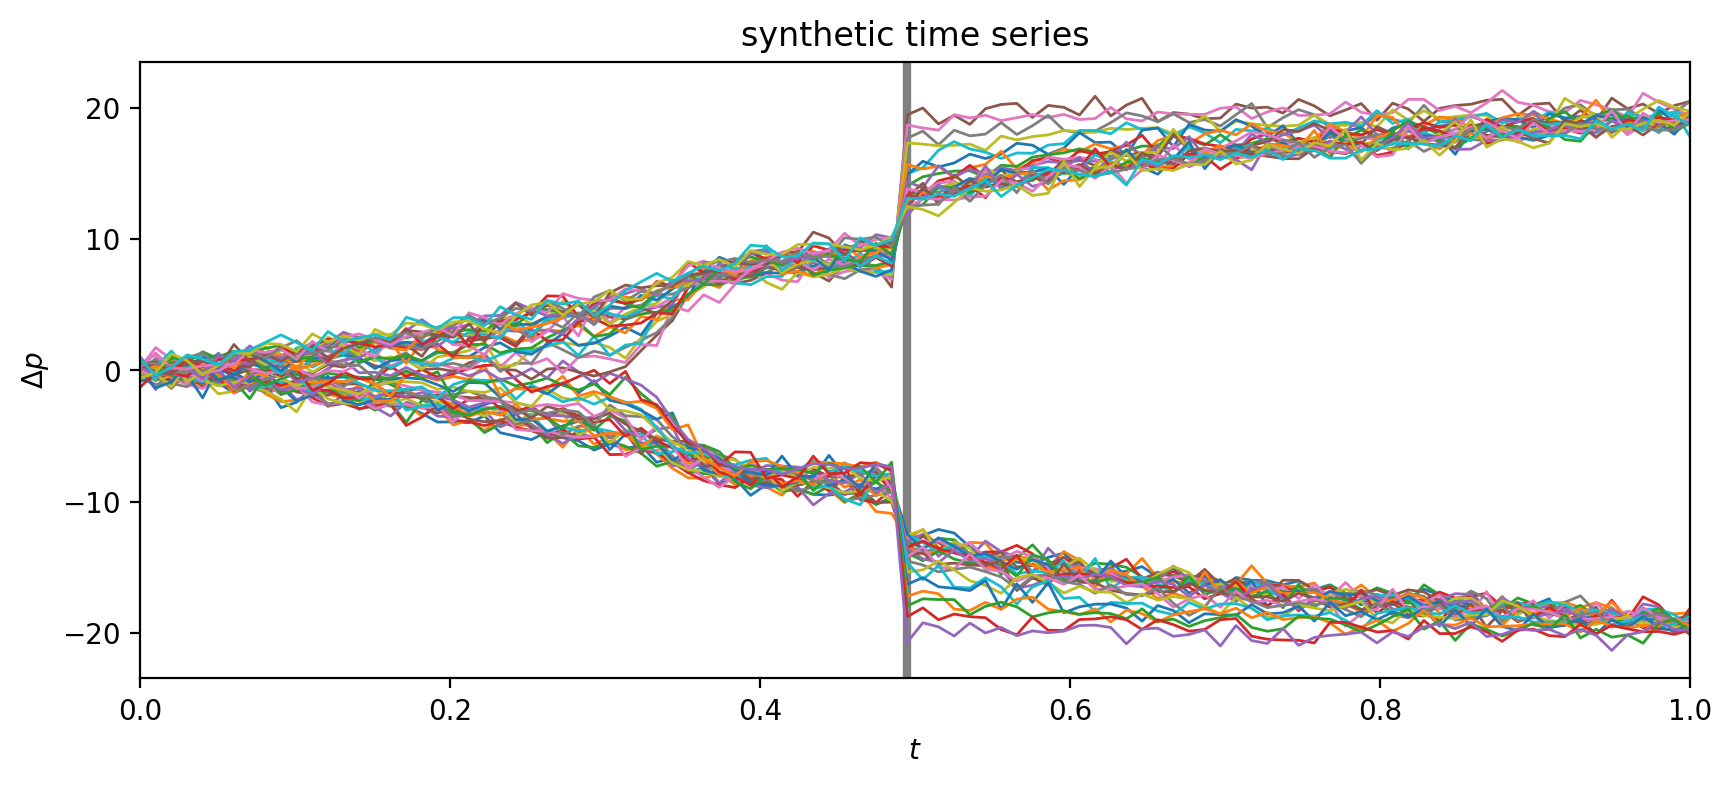

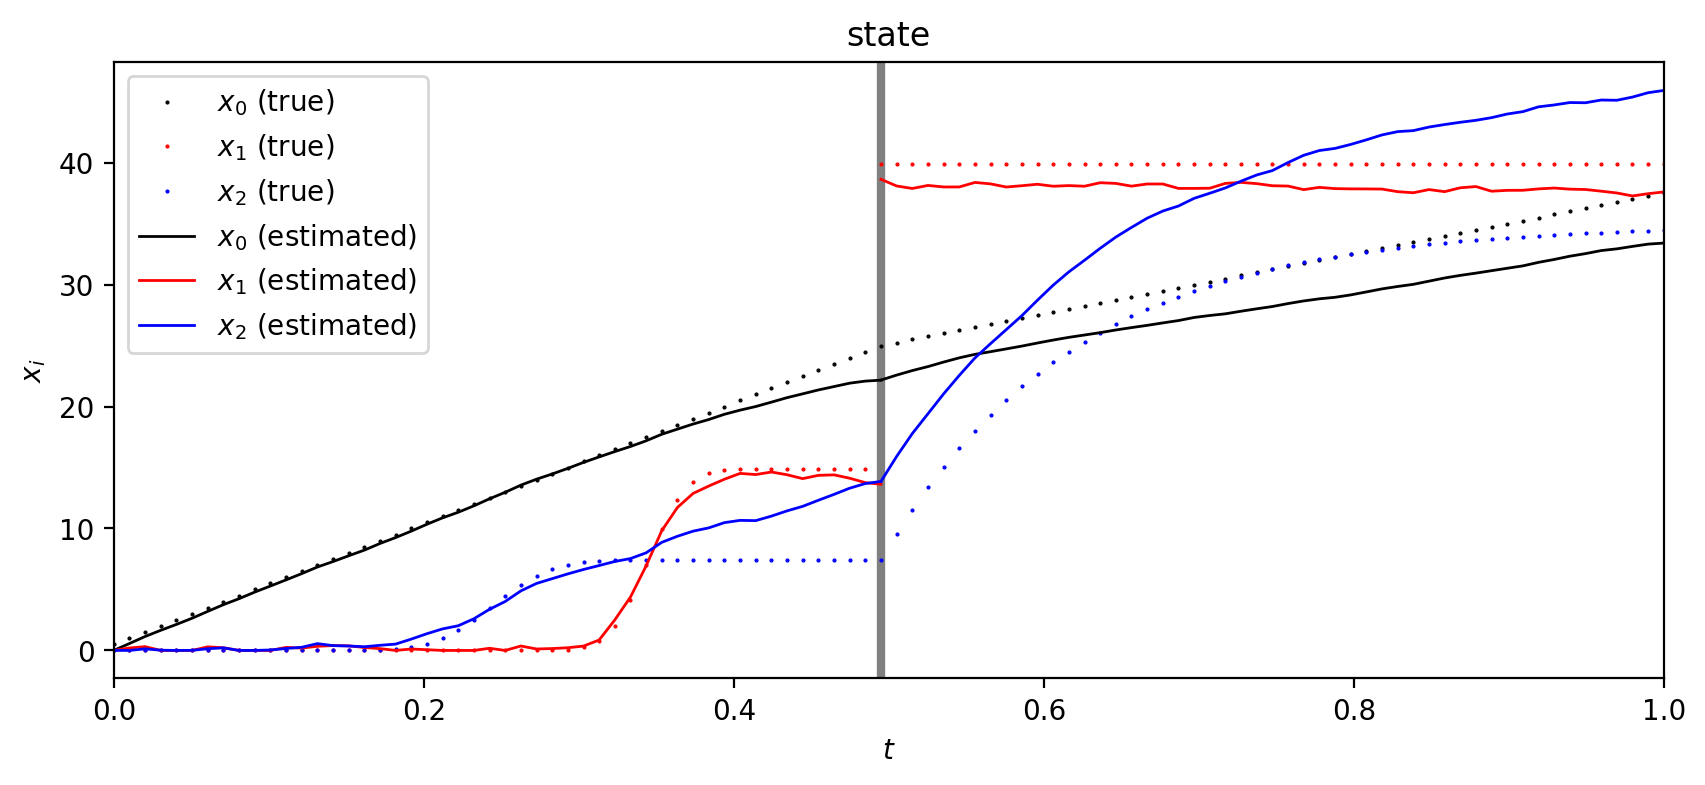

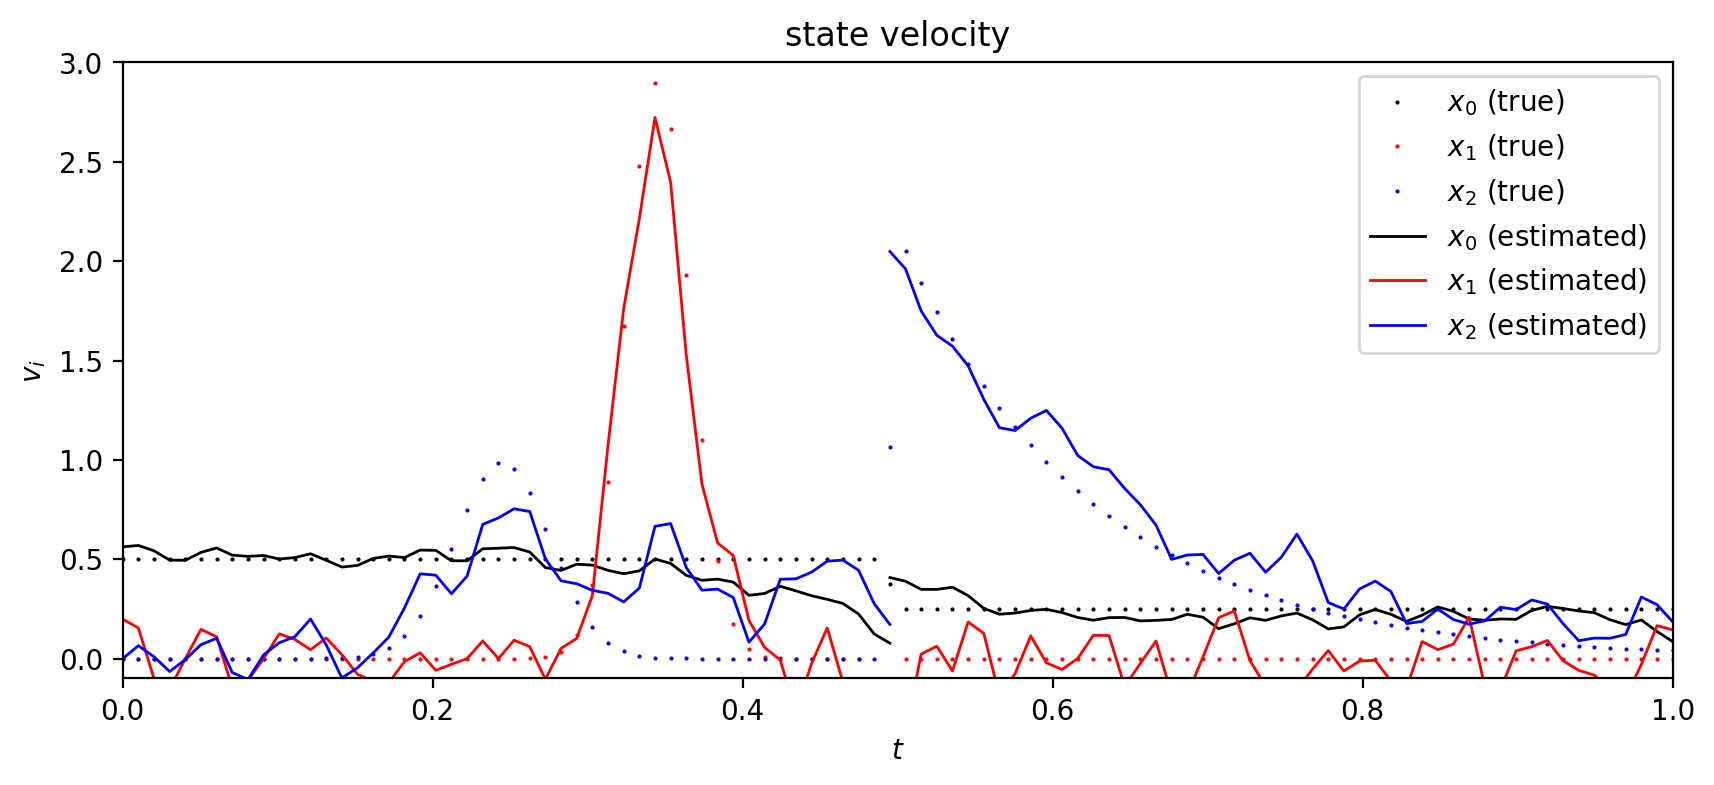

In [5]:
LINEWIDTH = 1.0

# Plot observed time series
plt.figure(figsize=(10, 4))
plt.axvline(x=t_vec[coseismic_idx], color="gray", linestyle="-", linewidth=3)
for i in range(50):
    plt.plot(
        t_vec,
        100 * b_noise[i, :],
        "-",
        linewidth=LINEWIDTH,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
plt.title("synthetic time series")
plt.show()

# Plot true and and estimated state
plt.figure(figsize=(10, 4))
plt.axvline(x=t_vec[coseismic_idx], color="gray", linestyle="-", linewidth=3)

# Plot true state
plt.plot(t_vec, x0, ".k", label="$x_0$ (true)", linewidth=LINEWIDTH, markersize=1.0)
plt.plot(t_vec, x1, ".r", label="$x_1$ (true)", linewidth=LINEWIDTH, markersize=1.0)
plt.plot(t_vec, x2, ".b", label="$x_2$ (true)", linewidth=LINEWIDTH, markersize=1.0)

# Plot first batch
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 0] / dt,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 1] / dt,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 2] / dt,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=LINEWIDTH,
)

# Plot second batch
plt.plot(t_vec[coseismic_idx::], x_est_post[:, 0] / dt, "-k", linewidth=LINEWIDTH)
plt.plot(
    t_vec[coseismic_idx::],
    x_est_post[:, 1] / dt + np.max(np.diff(x1)),
    "-r",
    linewidth=LINEWIDTH,
)
plt.plot(t_vec[coseismic_idx::], x_est_post[:, 2] / dt, "-b", linewidth=LINEWIDTH)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state")
plt.show()

plt.figure(figsize=(10, 4))

# Plot true state
plt.plot(
    t_vec,
    np.gradient(x0),
    ".k",
    label="$x_0$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)
plt.plot(
    t_vec,
    np.gradient(x1),
    ".r",
    label="$x_1$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)
plt.plot(
    t_vec,
    np.gradient(x2),
    ".b",
    label="$x_2$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)

# Plot first batch
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    np.gradient(x_est[:, 0] / dt),
    "-k",
    label="$x_0$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    np.gradient(x_est[:, 1] / dt),
    "-r",
    label="$x_1$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    np.gradient(x_est[:, 2] / dt),
    "-b",
    label="$x_2$ (estimated)",
    linewidth=LINEWIDTH,
)

# Plot second batch
plt.plot(
    t_vec[coseismic_idx::],
    np.gradient(x_est_post[:, 0] / dt),
    "-k",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[coseismic_idx::],
    np.gradient(x_est_post[:, 1] / dt + np.max(np.diff(x1))),
    "-r",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[coseismic_idx::],
    np.gradient(x_est_post[:, 2] / dt),
    "-b",
    linewidth=LINEWIDTH,
)

plt.xlabel("$t$")
plt.ylabel("$v_i$")
plt.xlim([0, 1])
plt.ylim([-0.1, 3])
plt.legend()
plt.title("state velocity")
plt.show()

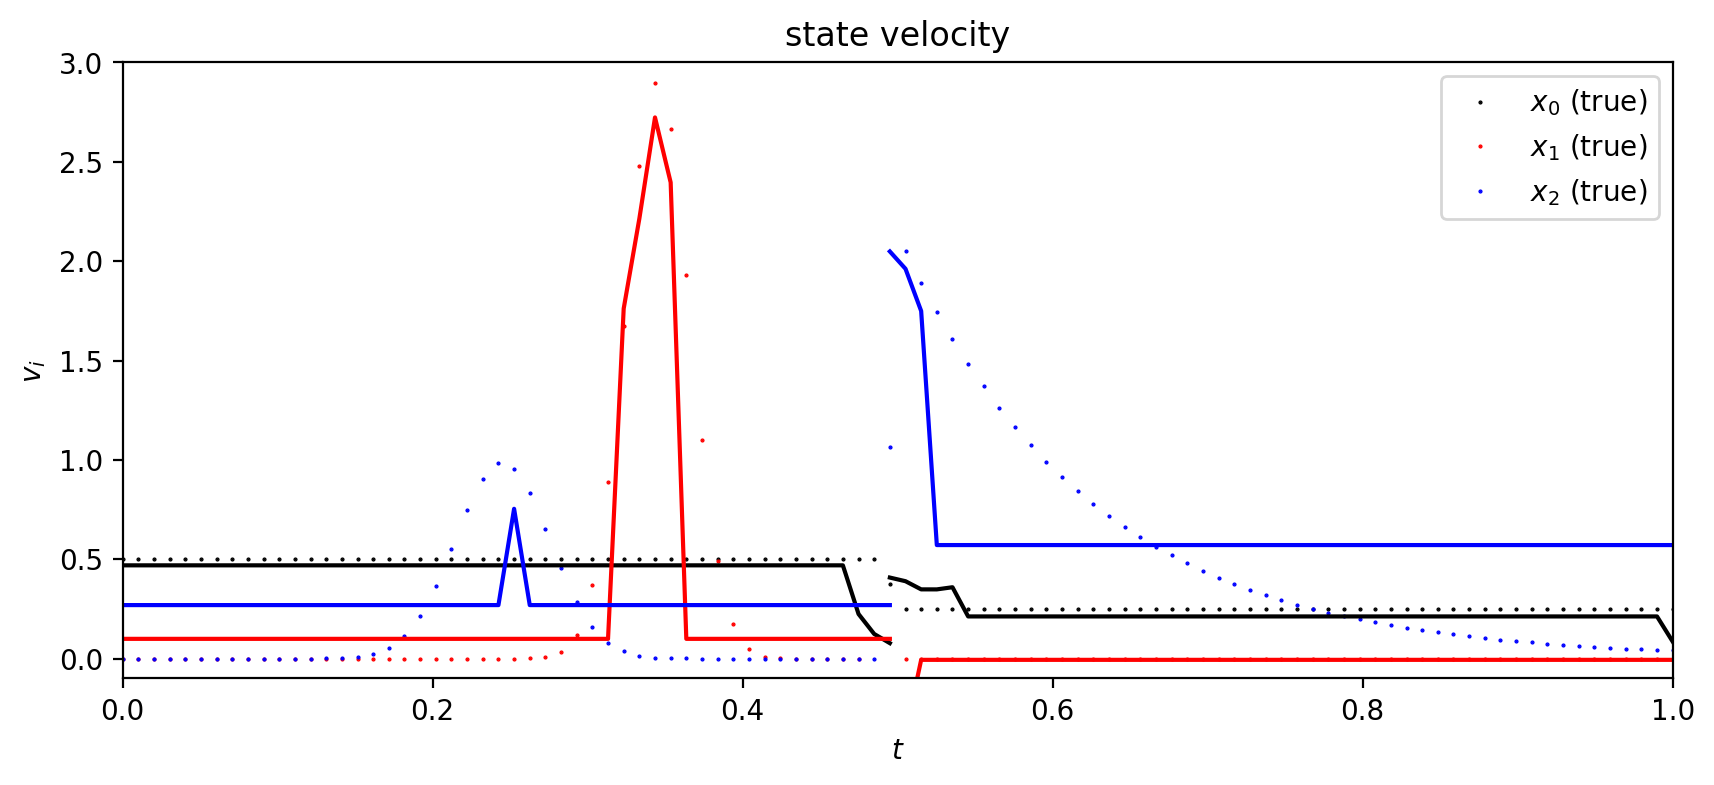

In [6]:
v0 = np.gradient(x_est[:, 0] / dt)
v1 = np.gradient(x_est[:, 1] / dt)
v2 = np.gradient(x_est[:, 2] / dt)
v0_mean = np.mean(v0)
v1_mean = np.mean(v1)
v2_mean = np.mean(v2)
v0_std = np.std(v0)
v1_std = np.std(v1)
v2_std = np.std(v2)

v0_post = np.gradient(x_est_post[:, 0] / dt)
v1_post = np.gradient(x_est_post[:, 1] / dt)
v2_post = np.gradient(x_est_post[:, 2] / dt)
v0_post_mean = np.mean(v0_post)
v1_post_mean = np.mean(v1_post)
v2_post_mean = np.mean(v2_post)
v0_post_std = np.std(v0_post)
v1_post_std = np.std(v1_post)
v2_post_std = np.std(v2_post)


plt.figure(figsize=(10, 4))
plt.plot(
    t_vec,
    np.gradient(x0),
    ".k",
    label="$x_0$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)
plt.plot(
    t_vec,
    np.gradient(x1),
    ".r",
    label="$x_1$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)
plt.plot(
    t_vec,
    np.gradient(x2),
    ".b",
    label="$x_2$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)

# Pre-event
v0_sig = np.zeros_like(v0)
idx = np.where(np.abs(v0 - v0_mean) > 2 * v0_std)[0]
v0_sig[idx] = v0[idx]
idx = np.where(np.abs(v0 - v0_mean) <= 2 * v0_std)[0]
v0_sig[idx] = np.mean(v0[idx])
plt.plot(t_vec[0 : coseismic_idx + 1], v0_sig, "-k")

v1_sig = np.zeros_like(v1)
idx = np.where(np.abs(v1 - v1_mean) > 2 * v1_std)[0]
v1_sig[idx] = v1[idx]
idx = np.where(np.abs(v1 - v1_mean) <= 2 * v1_std)[0]
v1_sig[idx] = np.mean(v1[idx])
plt.plot(t_vec[0 : coseismic_idx + 1], v1_sig, "-r")

v2_sig = np.zeros_like(v2)
idx = np.where(np.abs(v2 - v2_mean) > 2 * v2_std)[0]
v2_sig[idx] = v2[idx]
idx = np.where(np.abs(v2 - v2_mean) <= 2 * v2_std)[0]
v2_sig[idx] = np.mean(v2[idx])
plt.plot(t_vec[0 : coseismic_idx + 1], v2_sig, "-b")

# Post-event _post
v0_sig_post = np.zeros_like(v0_post)
idx = np.where(np.abs(v0_post - v0_post_mean) > 2 * v0_post_std)[0]
v0_sig_post[idx] = v0_post[idx]
idx = np.where(np.abs(v0_post - v0_post_mean) <= 2 * v0_post_std)[0]
v0_sig_post[idx] = np.mean(v0_post[idx])
plt.plot(t_vec[coseismic_idx::], v0_sig_post, "-k")

v1_sig_post = np.zeros_like(v1_post)
idx = np.where(np.abs(v1_post - v1_post_mean) > 2 * v1_post_std)[0]
v1_sig_post[idx] = v1_post[idx]
idx = np.where(np.abs(v1_post - v1_post_mean) <= 2 * v1_post_std)[0]
v1_sig_post[idx] = np.mean(v1_post[idx])
plt.plot(t_vec[coseismic_idx::], v1_sig_post, "-r")

v2_sig_post = np.zeros_like(v2_post)
idx = np.where(np.abs(v2_post - v2_post_mean) > 2 * v2_post_std)[0]
v2_sig_post[idx] = v2_post[idx]
idx = np.where(np.abs(v2_post - v2_post_mean) <= 2 * v2_post_std)[0]
v2_sig_post[idx] = np.mean(v2_post[idx])
plt.plot(t_vec[coseismic_idx::], v2_sig_post, "-b")


plt.xlabel("$t$")
plt.ylabel("$v_i$")
plt.xlim([0, 1])
plt.ylim([-0.1, 3])
plt.legend()
plt.title("state velocity")
plt.show()